# Chapter 16: Computation of the Trifocal Tensor T

Source orientation: printed pages 391-408; PDF pages 409-426. This notebook uses that source span for the topic order and mathematical coverage only. The prose, examples, data, visuals, and checks here are original, executable course material.

## Chapter Goal

Chapter 15 explains what the trifocal tensor does. This chapter asks how to estimate one from image data. The important shift is computational: a tensor is not accepted because it has 27 numbers, but because it is supported by trilinear equations, has a stable nullspace estimate, behaves sensibly under normalization, and produces small residuals on held-out or corrupted triplets. The notebook builds a deterministic synthetic three-view scene so the true camera-generated tensor is known. That lets every visual have a numerical check beside it.

The source chapter discusses linear estimation, normalization, internal constraints, algebraic and geometric minimization, Sampson approximation, and robust estimation. This notebook turns those themes into six inspectable experiments. It starts with the linear `A t = 0` system, compares raw and normalized conditioning, checks the recovered tensor slices against a camera-generated tensor, injects bad triplets to show why robust estimation is necessary, maps a local transfer residual landscape, and closes with an orthogonal-distance fitting panel that explains the geometric-error language behind refinement.


## Translation Guide

| Book concept | Computational object in this notebook | Inspection target |
| --- | --- | --- |
| Point-point-point trilinear relation | Four independent rows in a design matrix for each triplet | row sparsity and one-dimensional nullspace |
| Tensor entries | A `3 x 3 x 3` NumPy array, flattened only when solving `A t = 0` | slice heatmaps before and after scale alignment |
| Data normalization | Similarity transforms applied to image coordinates before forming `A` | smaller effective condition number |
| Internal constraints | Camera-generated tensor used as a ground-truth valid tensor | scaled tensor error and residual checks |
| Robust estimation | Residual comparison between clean and corrupted triplets | outlier residuals dominate the corrupted tail |

The synthetic data is deliberately small. A small scene makes it easy to see which part of the algorithm is being tested. If the nullspace is not isolated, the design matrix is not informative enough. If normalization does not improve the effective condition number, the coordinate scale is hiding the geometry. If a corrupted correspondence does not raise the trilinear residual, the residual is not a useful vote for RANSAC-style filtering.


## Library Routing And Visual Storyboard

This chapter is about computing a trifocal tensor from image correspondences, so the notebook keeps the algebra visible. **NumPy/SVD** builds and solves the linear `A t = 0` system because the main algorithm is a homogeneous nullspace estimate. **Matplotlib** is used for design-matrix sparsity, singular-value spectra, tensor-slice heatmaps, robust residual panels, and orthogonal-distance fitting because those diagnostics need to remain readable in static exports. **Plotly** is used for the local transfer residual surface because the Sampson/geometric-error idea is easier to inspect when the learner can rotate the basin. The examples use synthetic cameras and points so the true tensor is known and every residual can be checked without copying images, tables, or figures from the source.

| Visual | Artifact | What to inspect | Check |
| --- | --- | --- | --- |
| Trilinear equation design matrix | `figures/trilinear-equation-design-matrix.png` | each point triplet contributes four sparse equations in 27 tensor entries | design matrix has a one-dimensional nullspace |
| Normalization conditioning panel | `figures/normalization-conditioning-panel.png` | point normalization improves the conditioning before choosing the null vector | effective condition number decreases |
| Tensor slice estimation heatmaps | `figures/tensor-slice-estimation-heatmaps.png` | estimated slices match the camera-generated tensor up to scale | scaled tensor error is small |
| Robust residual vote panel | `figures/robust-trifocal-residual-votes.png` | corrupted triplets have larger trilinear residuals and can be rejected | outlier residual median exceeds clean median |
| Transfer residual landscape | `interactive/transfer-residual-landscape.html` | a local basin around the correct third-view point | minimum occurs at the unperturbed correspondence |
| Line orthogonal regression reduction | `figures/line-orthogonal-regression-reduction.png` | orthogonal geometric distance differs from vertical least squares | total least squares reduces orthogonal residual |


In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-16"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
BOOK_ROOT, ARTIFACT_ROOT


(WindowsPath('Multiple-View-Geometry-in-Computer-Vision'),
 WindowsPath('Multiple-View-Geometry-in-Computer-Vision/artifacts/chapter-16'))

In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html

ENTRY_TITLE = "Computation of the Trifocal Tensor T"
SEED = 316
rng = np.random.default_rng(SEED)
artifact_paths = []


def rotation_y(theta: float) -> np.ndarray:
    c, s = math.cos(theta), math.sin(theta)
    return np.array([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]])


def rotation_x(theta: float) -> np.ndarray:
    c, s = math.cos(theta), math.sin(theta)
    return np.array([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]])


def project(P: np.ndarray, X: np.ndarray) -> np.ndarray:
    Xh = np.column_stack([X, np.ones(len(X))])
    x = (P @ Xh.T).T
    return x / x[:, 2:3]


def trifocal_from_cameras(P2: np.ndarray, P3: np.ndarray) -> np.ndarray:
    A, a4 = P2[:, :3], P2[:, 3]
    B, b4 = P3[:, :3], P3[:, 3]
    tensor = np.empty((3, 3, 3))
    for i in range(3):
        tensor[i] = np.outer(A[:, i], b4) - np.outer(a4, B[:, i])
    return tensor


def trilinear_rows(x: np.ndarray, xp: np.ndarray, xpp: np.ndarray) -> list[np.ndarray]:
    rows = []
    for i in [0, 1]:
        for ell in [0, 1]:
            row = np.zeros(27)
            for k in range(3):
                row[k * 9 + 2 * 3 + 2] += x[k] * xp[i] * xpp[ell]
                row[k * 9 + i * 3 + 2] += -x[k] * xpp[ell]
                row[k * 9 + 2 * 3 + ell] += -x[k] * xp[i]
                row[k * 9 + i * 3 + ell] += x[k]
            rows.append(row)
    return rows


def design_matrix(x1: np.ndarray, x2: np.ndarray, x3: np.ndarray) -> np.ndarray:
    return np.vstack([row for triplet in zip(x1, x2, x3) for row in trilinear_rows(*triplet)])


def estimate_tensor(x1: np.ndarray, x2: np.ndarray, x3: np.ndarray):
    A = design_matrix(x1, x2, x3)
    _, s, vt = np.linalg.svd(A)
    return vt[-1].reshape(3, 3, 3), A, s


def scale_to_reference(T_est: np.ndarray, T_ref: np.ndarray):
    scale = float(np.vdot(T_ref, T_est) / np.vdot(T_est, T_est))
    aligned = scale * T_est
    return aligned, float(np.linalg.norm(T_ref - aligned) / np.linalg.norm(T_ref))


def trilinear_residuals(T: np.ndarray, x1: np.ndarray, x2: np.ndarray, x3: np.ndarray) -> np.ndarray:
    t = T.reshape(-1)
    return np.array([np.linalg.norm(design_matrix(a[None, :], b[None, :], c[None, :]) @ t) for a, b, c in zip(x1, x2, x3)])


def normalize_points(points: np.ndarray) -> np.ndarray:
    xy = points[:, :2] / points[:, 2:3]
    center = xy.mean(axis=0)
    shifted = xy - center
    rms = np.sqrt(np.mean(np.sum(shifted**2, axis=1)))
    scale = np.sqrt(2.0) / max(rms, 1e-12)
    H = np.array([[scale, 0.0, -scale * center[0]], [0.0, scale, -scale * center[1]], [0.0, 0.0, 1.0]])
    normalized = (H @ points.T).T
    return normalized / normalized[:, 2:3]

P1 = np.hstack([np.eye(3), np.zeros((3, 1))])
P2 = np.hstack([rotation_y(math.radians(8.0)) @ rotation_x(math.radians(-2.5)), np.array([[0.72], [0.06], [0.18]])])
P3 = np.hstack([rotation_y(math.radians(-6.5)) @ rotation_x(math.radians(4.0)), np.array([[-0.42], [0.18], [0.26]])])
points3d = rng.uniform([-0.9, -0.7, 3.2], [0.9, 0.8, 5.0], size=(18, 3))
x1 = project(P1, points3d)
x2 = project(P2, points3d)
x3 = project(P3, points3d)
T_true = trifocal_from_cameras(P2, P3)
T_est, A, singular_values = estimate_tensor(x1, x2, x3)
T_scaled, relative_tensor_error = scale_to_reference(T_est, T_true)
x1_norm, x2_norm, x3_norm = [normalize_points(x) for x in [x1, x2, x3]]
_, A_norm, singular_values_norm = estimate_tensor(x1_norm, x2_norm, x3_norm)
source_span = {"printed_pages": "391-408", "pdf_pages": "409-426"}
source_span


{'printed_pages': '391-408', 'pdf_pages': '409-426'}

## 1. Trilinear Equations as a Nullspace Problem

The first computation expands a point triplet into four independent rows. With eighteen synthetic triplets, the design matrix has seventy-two rows and twenty-seven columns. The final singular value should be tiny because the triplets were generated from cameras, and the next singular value should be separated from it because the data determines one homogeneous tensor up to scale.


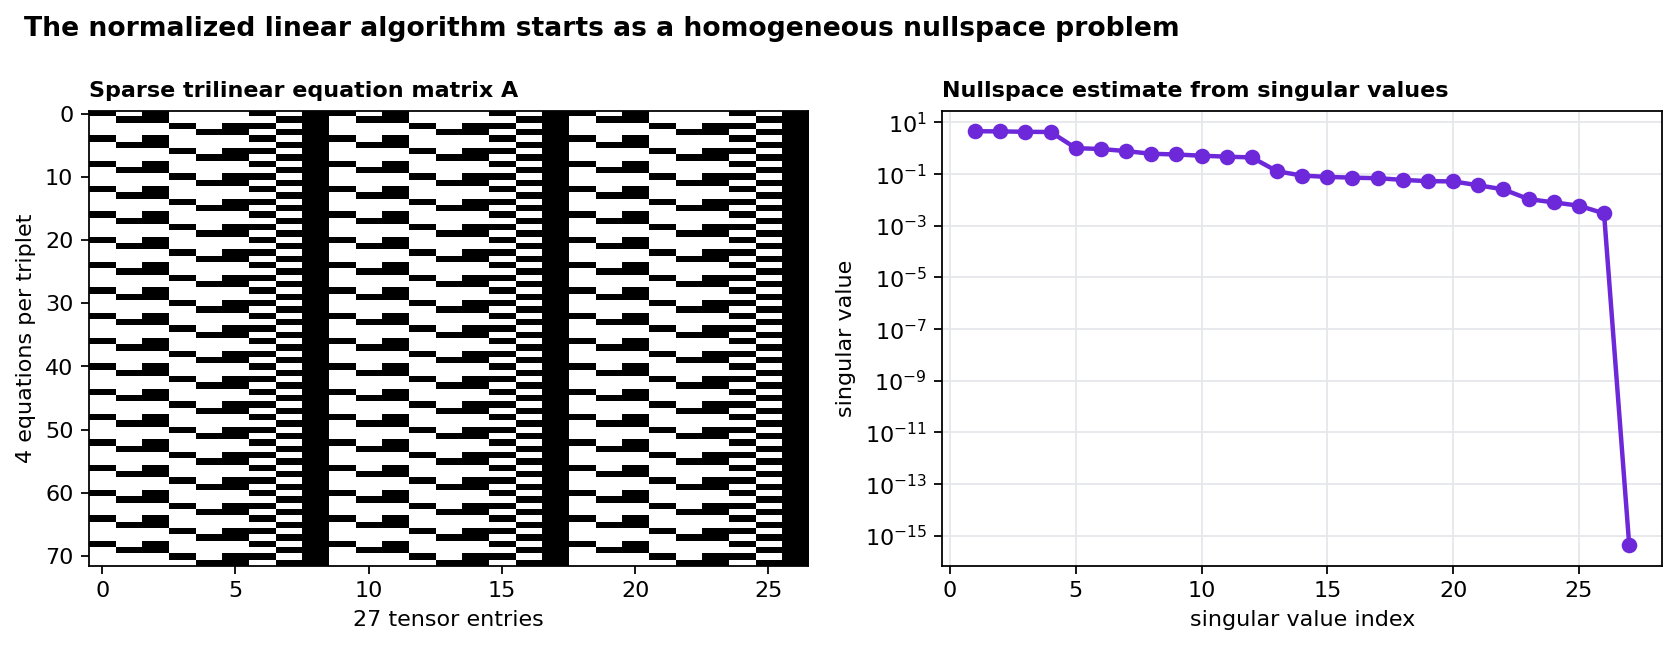

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.1))
axes[0].imshow(np.abs(A) > 1e-12, cmap="Greys", aspect="auto")
axes[0].set_title("Sparse trilinear equation matrix A", loc="left", fontsize=10, fontweight="bold")
axes[0].set_xlabel("27 tensor entries")
axes[0].set_ylabel("4 equations per triplet")
axes[1].semilogy(np.arange(1, len(singular_values) + 1), singular_values, marker="o", color="#6d28d9", lw=2.0)
axes[1].set_title("Nullspace estimate from singular values", loc="left", fontsize=10, fontweight="bold")
axes[1].set_xlabel("singular value index")
axes[1].set_ylabel("singular value")
axes[1].grid(True, color="#e5e7eb")
fig.suptitle("The normalized linear algorithm starts as a homogeneous nullspace problem", x=0.02, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
design_path = save_matplotlib(fig, TOPIC, "figures", "trilinear-equation-design-matrix.png")
plt.close(fig)
artifact_paths.append(design_path)
display_artifact(design_path, width=900)


## 2. Normalization And Conditioning

The source chapter emphasizes normalization before solving the linear equations. The point is not cosmetic. Raw image coordinates can make some rows of `A` dominate others. Normalizing each image so points are centered and have comparable RMS distance makes the effective singular spectrum easier to interpret before the null vector is selected.


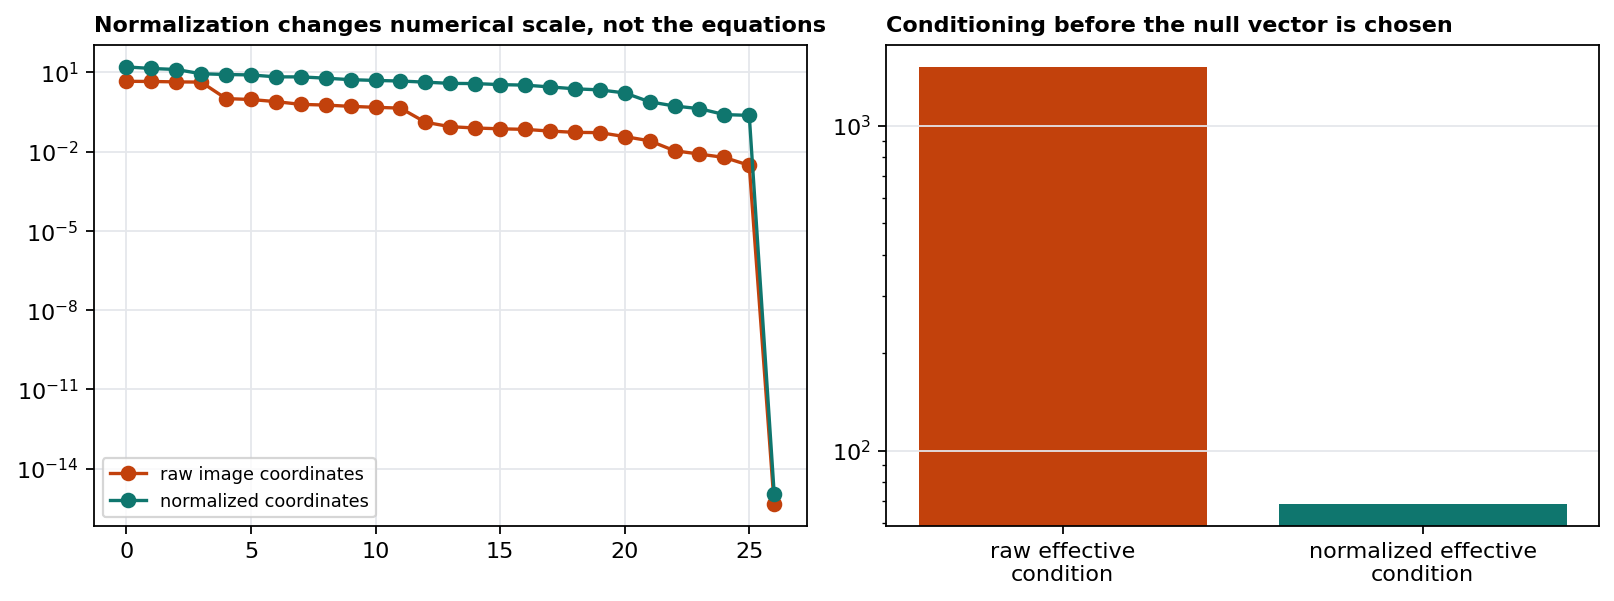

In [4]:
raw_gap = float(singular_values[-2] / max(singular_values[-1], 1e-18))
norm_gap = float(singular_values_norm[-2] / max(singular_values_norm[-1], 1e-18))
raw_condition = float(singular_values[0] / max(singular_values[-2], 1e-18))
norm_condition = float(singular_values_norm[0] / max(singular_values_norm[-2], 1e-18))
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9))
axes[0].semilogy(singular_values, marker="o", color="#c2410c", label="raw image coordinates")
axes[0].semilogy(singular_values_norm, marker="o", color="#0f766e", label="normalized coordinates")
axes[0].set_title("Normalization changes numerical scale, not the equations", loc="left", fontsize=10, fontweight="bold")
axes[0].grid(True, color="#e5e7eb")
axes[0].legend(fontsize=8)
axes[1].bar(["raw effective/ncondition", "normalized effective/ncondition"], [raw_condition, norm_condition], color=["#c2410c", "#0f766e"])
axes[1].set_yscale("log")
axes[1].set_title("Conditioning before the null vector is chosen", loc="left", fontsize=10, fontweight="bold")
axes[1].grid(True, axis="y", color="#e5e7eb")
fig.tight_layout()
conditioning_path = save_matplotlib(fig, TOPIC, "figures", "normalization-conditioning-panel.png")
plt.close(fig)
artifact_paths.append(conditioning_path)
display_artifact(conditioning_path, width=860)


## 3. Tensor Slices And Internal Validity

A linear null vector alone is only an estimate. To keep the check concrete, the notebook compares it with the tensor produced directly from the synthetic second and third camera matrices. Since tensors are homogeneous, the comparison first aligns the estimated tensor by one scalar and then inspects the three matrix slices.


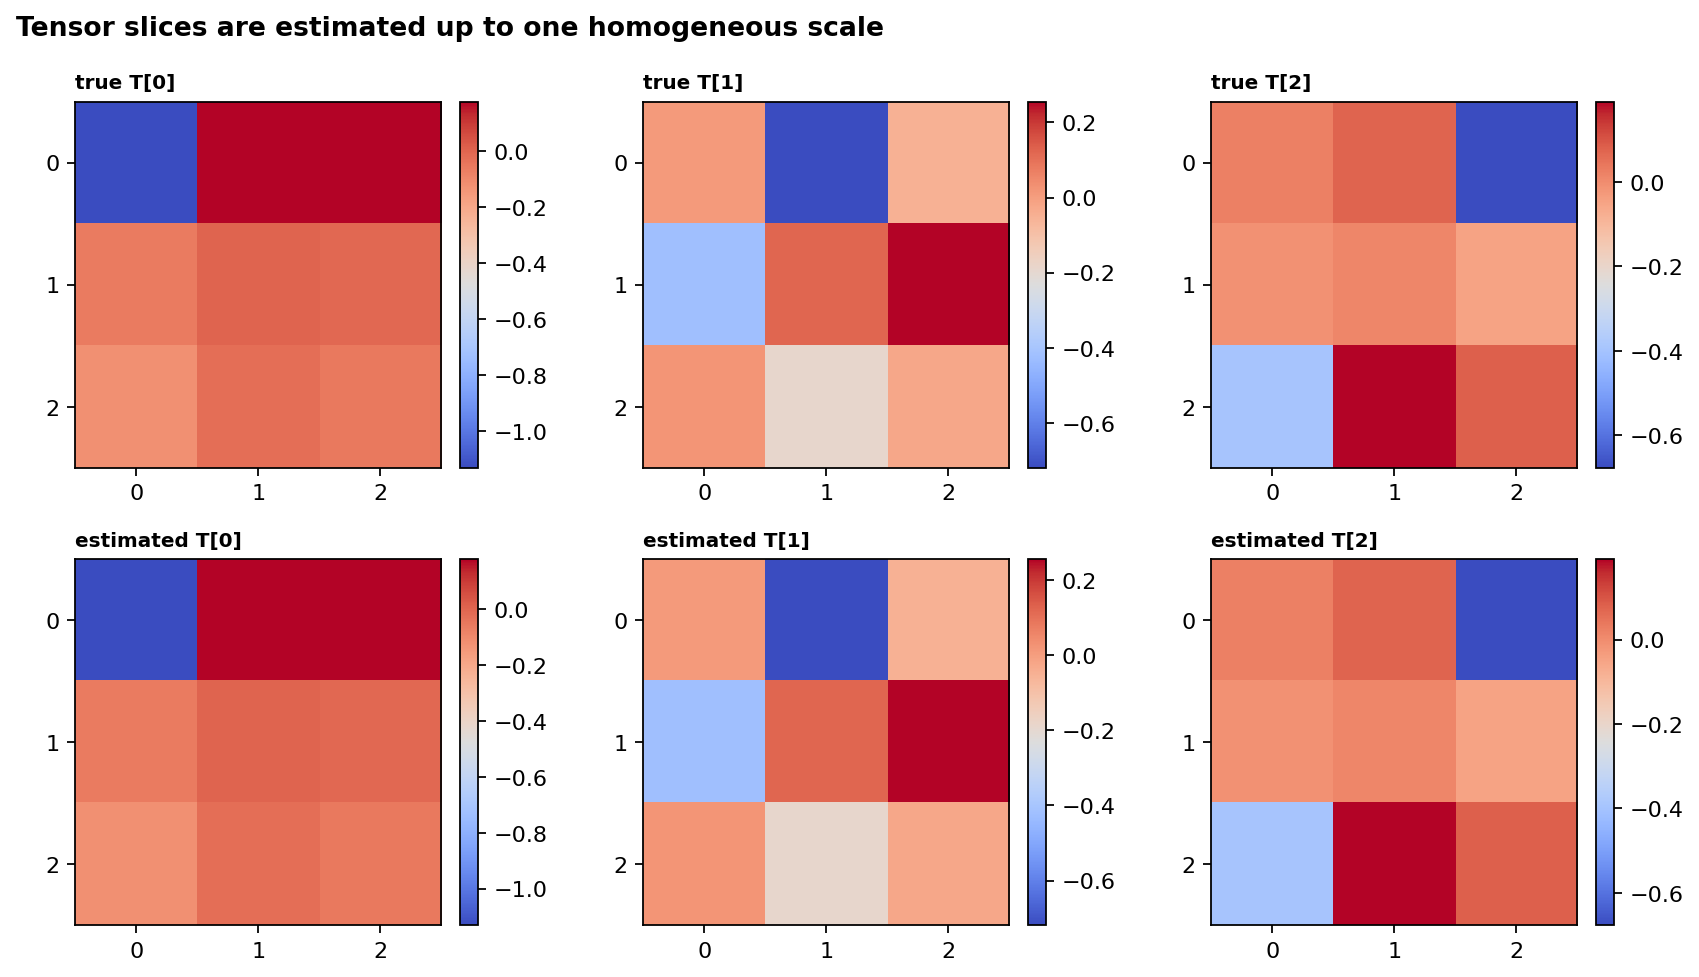

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(10.8, 6.2))
for i in range(3):
    im0 = axes[0, i].imshow(T_true[i], cmap="coolwarm")
    axes[0, i].set_title(f"true T[{i}]", loc="left", fontsize=9, fontweight="bold")
    fig.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)
    im1 = axes[1, i].imshow(T_scaled[i], cmap="coolwarm")
    axes[1, i].set_title(f"estimated T[{i}]", loc="left", fontsize=9, fontweight="bold")
    fig.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)
    for ax in [axes[0, i], axes[1, i]]:
        ax.set_xticks(range(3))
        ax.set_yticks(range(3))
fig.suptitle("Tensor slices are estimated up to one homogeneous scale", x=0.02, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
slice_path = save_matplotlib(fig, TOPIC, "figures", "tensor-slice-estimation-heatmaps.png")
plt.close(fig)
artifact_paths.append(slice_path)
display_artifact(slice_path, width=900)


## 4. Robust Residuals And Bad Triplets

The robust-estimation section of the chapter matters because real point tracks contain mismatches. The experiment below deliberately corrupts the last four third-view points by cyclically permuting them. A useful residual should stay small for the camera-generated triplets and grow sharply on the corrupted tail. This is the same diagnostic idea behind a RANSAC vote, expressed here without hiding the tensor equations.


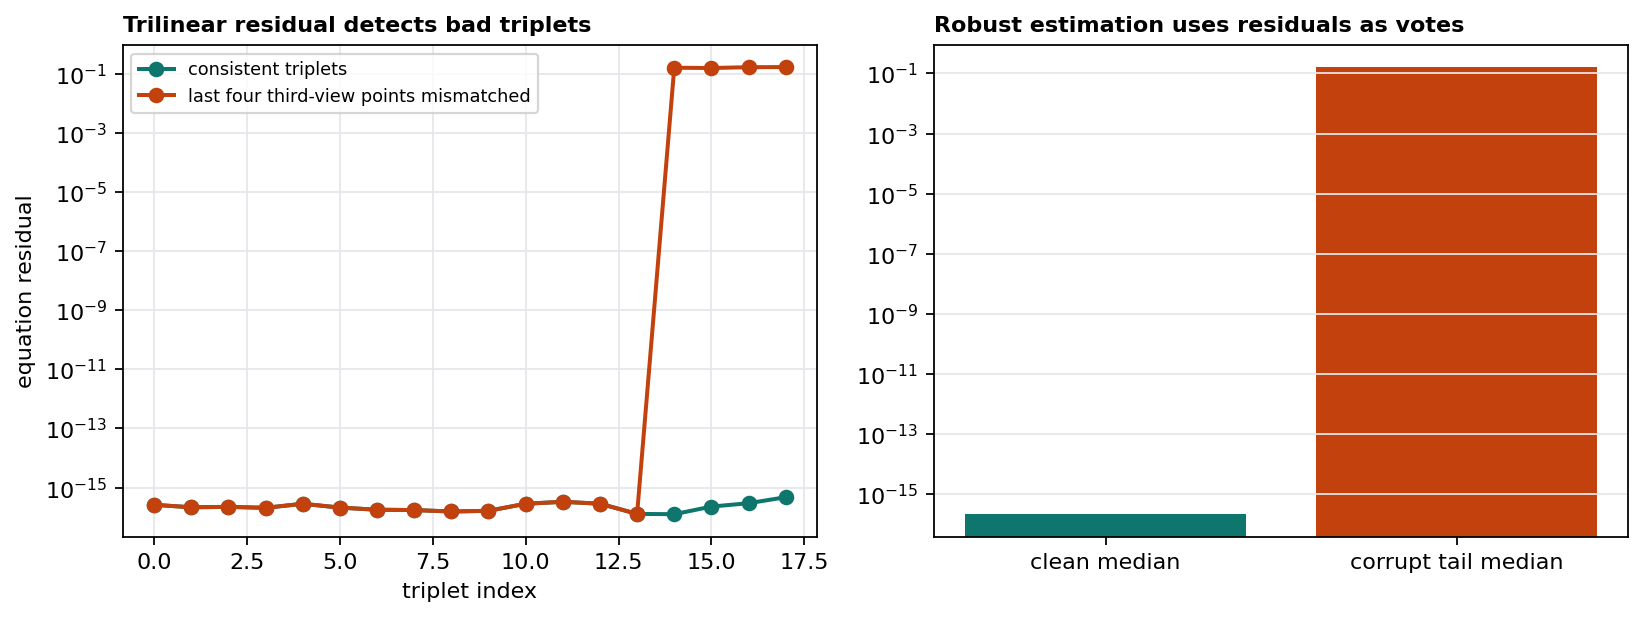

In [6]:
x3_corrupt = x3.copy()
x3_corrupt[-4:] = np.roll(x3_corrupt[-4:], shift=1, axis=0)
residual_clean = trilinear_residuals(T_scaled, x1, x2, x3)
residual_corrupt = trilinear_residuals(T_scaled, x1, x2, x3_corrupt)
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0))
axes[0].plot(residual_clean, marker="o", color="#0f766e", lw=1.8, label="consistent triplets")
axes[0].plot(residual_corrupt, marker="o", color="#c2410c", lw=1.8, label="last four third-view points mismatched")
axes[0].set_yscale("log")
axes[0].set_title("Trilinear residual detects bad triplets", loc="left", fontsize=10, fontweight="bold")
axes[0].set_xlabel("triplet index")
axes[0].set_ylabel("equation residual")
axes[0].grid(True, color="#e5e7eb")
axes[0].legend(fontsize=8)
axes[1].bar(["clean median", "corrupt tail median"], [np.median(residual_clean), np.median(residual_corrupt[-4:])], color=["#0f766e", "#c2410c"])
axes[1].set_yscale("log")
axes[1].set_title("Robust estimation uses residuals as votes", loc="left", fontsize=10, fontweight="bold")
axes[1].grid(True, axis="y", color="#e5e7eb")
fig.tight_layout()
robust_path = save_matplotlib(fig, TOPIC, "figures", "robust-trifocal-residual-votes.png")
plt.close(fig)
artifact_paths.append(robust_path)
display_artifact(robust_path, width=880)


## 5. Sampson-Style Transfer Residual Landscape

A nonlinear refinement does not merely ask whether a correspondence is exact; it asks how the residual changes when an image measurement moves. The interactive artifact `interactive/transfer-residual-landscape.html` samples the trilinear residual around one third-view point. The basin has its minimum at the unperturbed point, which is the local picture that motivates first-order Sampson and geometric-error refinements.

In [7]:
target = 7
deltas = np.linspace(-0.055, 0.055, 45)
residual_surface = np.empty((len(deltas), len(deltas)))
base = x3[target].copy()
for row, dy in enumerate(deltas):
    for col, dx in enumerate(deltas):
        probe = np.array([base[0] + dx, base[1] + dy, 1.0])
        residual_surface[row, col] = np.linalg.norm(design_matrix(x1[target:target+1], x2[target:target+1], probe[None, :]) @ T_scaled.reshape(-1))
min_index = np.unravel_index(np.argmin(residual_surface), residual_surface.shape)
residual_min_offset = float(np.hypot(deltas[min_index[1]], deltas[min_index[0]]))

surface_fig = go.Figure(
    data=[go.Surface(x=deltas, y=deltas, z=residual_surface, colorscale="Viridis", showscale=True)]
)
surface_fig.update_layout(
    title="Local trilinear transfer residual around a correct third-view point",
    scene=dict(xaxis_title="delta x3", yaxis_title="delta y3", zaxis_title="residual"),
    margin=dict(l=0, r=0, t=42, b=0),
)
landscape_path = save_plotly_html(surface_fig, TOPIC, "interactive", "transfer-residual-landscape.html")
artifact_paths.append(landscape_path)
display_artifact(landscape_path, width=860, height=520)
{"minimum_offset": residual_min_offset, "minimum_residual": float(residual_surface[min_index])}


.venv/Lib/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'minimum_offset': 0.0, 'minimum_residual': 1.7253305394310741e-16}

## 6. Orthogonal Regression As Geometric Error

Linear tensor estimation gives an initializer; refinement chooses a geometric error. The panel `figures/line-orthogonal-regression-reduction.png` uses a small image-line fitting problem to show the distinction. Vertical least squares measures only image `y` error, while orthogonal regression measures distance perpendicular to the fitted line. That perpendicular distance is the same kind of measurement-space correction used by geometric tensor refinement.

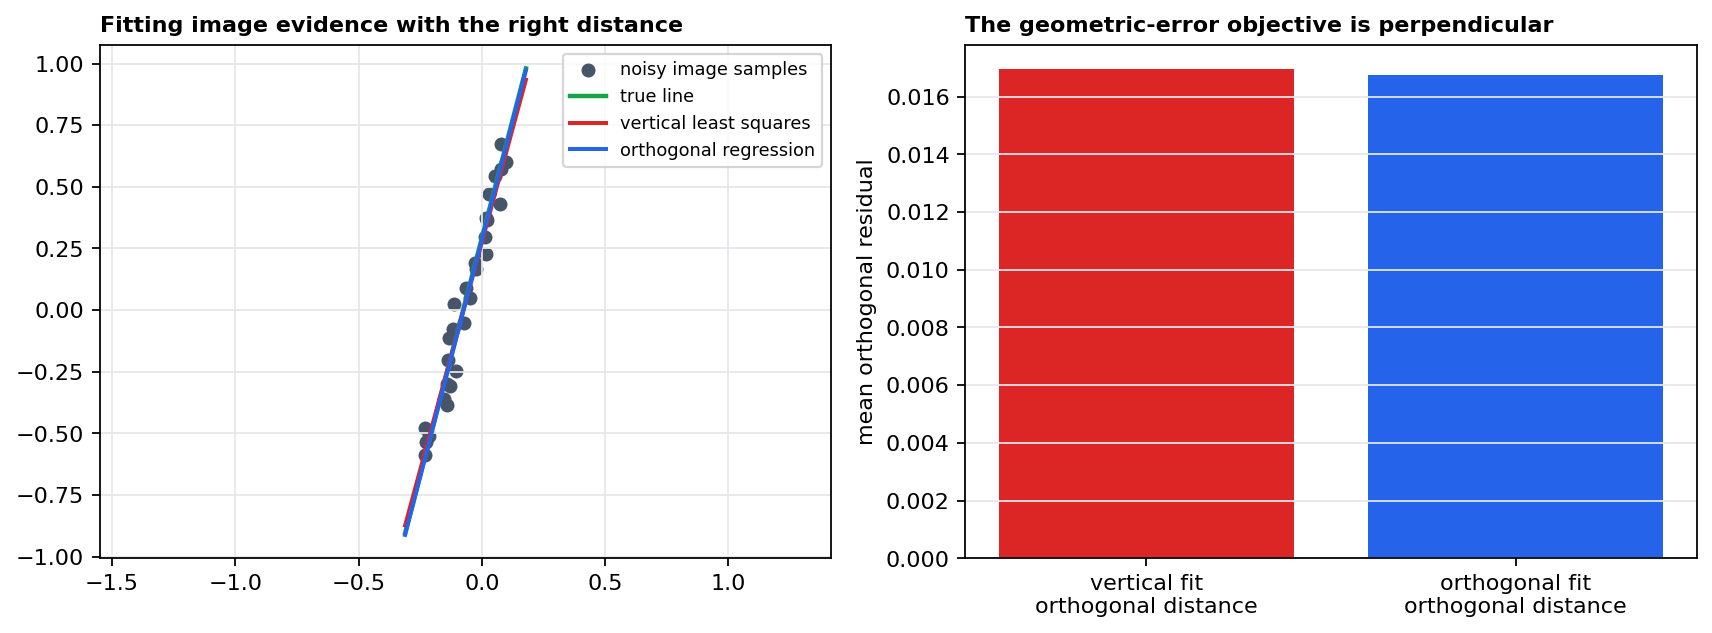

{'orthogonal_regression_improvement': 1.0113747028529314}

In [8]:
line_rng = np.random.default_rng(SEED + 16)
line_t = np.linspace(-0.65, 0.65, 28)
line_direction = np.array([0.26, 1.0])
line_direction = line_direction / np.linalg.norm(line_direction)
line_center = x3[target, :2]
line_points = line_center + line_t[:, None] * line_direction
noisy_line_points = line_points + line_rng.normal(scale=[0.018, 0.018], size=line_points.shape)

vertical_slope, vertical_intercept = np.polyfit(noisy_line_points[:, 0], noisy_line_points[:, 1], 1)
center = noisy_line_points.mean(axis=0)
_, _, vh = np.linalg.svd(noisy_line_points - center, full_matrices=False)
tls_direction = vh[0]
tls_normal = np.array([-tls_direction[1], tls_direction[0]])
tls_normal = tls_normal / np.linalg.norm(tls_normal)
tls_intercept = -float(tls_normal @ center)

vertical_orth = np.abs(noisy_line_points[:, 1] - (vertical_slope * noisy_line_points[:, 0] + vertical_intercept)) / np.sqrt(vertical_slope**2 + 1.0)
tls_orth = np.abs(noisy_line_points @ tls_normal + tls_intercept)
orthogonal_regression_improvement = float(vertical_orth.mean() / tls_orth.mean())

xx = np.linspace(noisy_line_points[:, 0].min() - 0.08, noisy_line_points[:, 0].max() + 0.08, 120)
vertical_yy = vertical_slope * xx + vertical_intercept
tls_yy = -(tls_normal[0] * xx + tls_intercept) / tls_normal[1]
true_yy = line_center[1] + (line_direction[1] / line_direction[0]) * (xx - line_center[0])

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.1))
axes[0].scatter(noisy_line_points[:, 0], noisy_line_points[:, 1], s=28, color="#475569", label="noisy image samples")
axes[0].plot(xx, true_yy, color="#16a34a", lw=2.0, label="true line")
axes[0].plot(xx, vertical_yy, color="#dc2626", lw=1.8, label="vertical least squares")
axes[0].plot(xx, tls_yy, color="#2563eb", lw=1.8, label="orthogonal regression")
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].set_title("Fitting image evidence with the right distance", loc="left", fontsize=10, fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(True, color="#e5e7eb")
axes[1].bar(["vertical fit/northogonal distance", "orthogonal fit/northogonal distance"], [vertical_orth.mean(), tls_orth.mean()], color=["#dc2626", "#2563eb"])
axes[1].set_title("The geometric-error objective is perpendicular", loc="left", fontsize=10, fontweight="bold")
axes[1].set_ylabel("mean orthogonal residual")
axes[1].grid(True, axis="y", color="#e5e7eb")
fig.tight_layout()
line_fit_path = save_matplotlib(fig, TOPIC, "figures", "line-orthogonal-regression-reduction.png")
plt.close(fig)
artifact_paths.append(line_fit_path)
display_artifact(line_fit_path, width=880)
{"orthogonal_regression_improvement": orthogonal_regression_improvement}


## Applied Lab

To adapt this notebook to measured triplets, keep the same checks. Replace `x1`, `x2`, and `x3` with homogeneous image coordinates from three views. Normalize the coordinates before forming `A`. Estimate the tensor, then inspect the singular gap and the residual distribution. If there is no isolated nullspace, add more correspondences or improve track quality. If residuals cluster into two groups, use a robust estimator and compare the accepted inliers with the visual track geometry.

The notebook does not implement the full constrained nonlinear optimizer from the chapter. Instead, it gives the audit trail that such an optimizer needs: a sane initializer, a normalization diagnostic, an internally valid reference construction, and residuals that distinguish good and bad triplets.


In [9]:
trifocal_checks = {
    "source_span": source_span,
    "libraries": ["numpy SVD/nullspace estimation", "matplotlib matrix/tensor/residual diagnostics", "plotly residual surface", "course artifact helpers"],
    "design_matrix_shape": list(A.shape),
    "nullspace_gap": raw_gap,
    "normalized_nullspace_gap": norm_gap,
    "raw_effective_condition": raw_condition,
    "normalized_effective_condition": norm_condition,
    "conditioning_improvement_factor": raw_condition / norm_condition,
    "relative_tensor_error_scaled": relative_tensor_error,
    "clean_residual_median": float(np.median(residual_clean)),
    "corrupt_tail_residual_median": float(np.median(residual_corrupt[-4:])),
    "outlier_residual_ratio": float(np.median(residual_corrupt[-4:]) / max(np.median(residual_clean), 1e-18)),
    "residual_landscape_min_offset": residual_min_offset,
    "orthogonal_regression_improvement": orthogonal_regression_improvement,
    "artifact_count": len(artifact_paths),
}
checks_path = save_json(trifocal_checks, TOPIC, "checks", "trifocal-estimation-invariants.json")
display_artifact(checks_path)
trifocal_checks


`artifacts/chapter-16/checks/trifocal-estimation-invariants.json`

{'source_span': {'printed_pages': '391-408', 'pdf_pages': '409-426'},
 'libraries': ['numpy SVD/nullspace estimation',
  'matplotlib matrix/tensor/residual diagnostics',
  'plotly residual surface',
  'course artifact helpers'],
 'design_matrix_shape': [72, 27],
 'nullspace_gap': 6730783691929.79,
 'normalized_nullspace_gap': 202913052094955.38,
 'raw_effective_condition': 1516.783618189331,
 'normalized_effective_condition': 68.25683908422972,
 'conditioning_improvement_factor': 22.221709041017892,
 'relative_tensor_error_scaled': 8.951880477263001e-15,
 'clean_residual_median': 2.1781486069521148e-16,
 'corrupt_tail_residual_median': 0.16210777439694218,
 'outlier_residual_ratio': 744245704262482.5,
 'residual_landscape_min_offset': 0.0,
 'orthogonal_regression_improvement': 1.0113747028529314,
 'artifact_count': 6}

## Final Sanity Checks

The final cell turns the visual claims into assertions. The design matrix must have the expected size, the nullspace must be isolated, normalization must improve the effective condition number, the recovered tensor must agree with the camera-generated tensor up to homogeneous scale, corrupted triplets must have much larger residuals, and all artifacts must be present and nontrivial.


In [10]:
final_sanity = {
    "artifact_count": len(artifact_paths),
    "all_artifacts": [str(path.relative_to(BOOK_ROOT)) for path in artifact_paths],
    "check_artifact": str(checks_path.relative_to(BOOK_ROOT)),
    "relative_tensor_error_scaled": trifocal_checks["relative_tensor_error_scaled"],
    "nullspace_gap": trifocal_checks["nullspace_gap"],
    "conditioning_improvement_factor": trifocal_checks["conditioning_improvement_factor"],
    "outlier_residual_ratio": trifocal_checks["outlier_residual_ratio"],
    "residual_landscape_min_offset": trifocal_checks["residual_landscape_min_offset"],
    "orthogonal_regression_improvement": trifocal_checks["orthogonal_regression_improvement"],
}
assert_artifacts(artifact_paths, min_bytes=1500)
assert checks_path.exists() and checks_path.stat().st_size > 200
assert final_sanity["artifact_count"] >= 6
assert trifocal_checks["design_matrix_shape"] == [72, 27]
assert trifocal_checks["nullspace_gap"] > 1e8
assert trifocal_checks["normalized_nullspace_gap"] > 1e8
assert trifocal_checks["conditioning_improvement_factor"] > 2.0
assert trifocal_checks["relative_tensor_error_scaled"] < 1e-10
assert trifocal_checks["outlier_residual_ratio"] > 1e6
assert trifocal_checks["residual_landscape_min_offset"] < 1e-12
assert trifocal_checks["orthogonal_regression_improvement"] > 1.0
final_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
final_sanity


{'artifact_count': 6,
 'all_artifacts': ['artifacts//chapter-16//figures//trilinear-equation-design-matrix.png',
  'artifacts//chapter-16//figures//normalization-conditioning-panel.png',
  'artifacts//chapter-16//figures//tensor-slice-estimation-heatmaps.png',
  'artifacts//chapter-16//figures//robust-trifocal-residual-votes.png',
  'artifacts//chapter-16//interactive//transfer-residual-landscape.html',
  'artifacts//chapter-16//figures//line-orthogonal-regression-reduction.png'],
 'check_artifact': 'artifacts//chapter-16//checks//trifocal-estimation-invariants.json',
 'relative_tensor_error_scaled': 8.951880477263001e-15,
 'nullspace_gap': 6730783691929.79,
 'conditioning_improvement_factor': 22.221709041017892,
 'outlier_residual_ratio': 744245704262482.5,
 'residual_landscape_min_offset': 0.0,
 'orthogonal_regression_improvement': 1.0113747028529314}

## Takeaways

- Trifocal estimation begins as a homogeneous linear system, but the rows only become numerically meaningful after normalization.
- A tensor estimate is scale-free, so comparisons and checks must align scale before measuring error.
- Internal validity matters because arbitrary 27-entry arrays can satisfy a noisy linear system without corresponding to cameras.
- Robust estimation is not a separate decorative topic: bad triplets visibly separate in the residual plot, which is why RANSAC-style voting is natural.
- The artifacts in this notebook are book-local and concept-named, so the chapter can be audited without the textbook open.
